# Quantum power flow: a guided paper reproduction

This notebook introduces quantum computing through an electricity-network application. You do **not** need prior knowledge of quantum computing or linear algebra. Run the cells from top to bottom.

By the end, you will have:

- calculated voltages in a five-bus electricity network;
- compared a classical calculation with a simulation of the Harrow–Hassidim–Lloyd (HHL) quantum algorithm;
- changed electricity demand and observed the result;
- changed quantum precision and observed the accuracy–resource trade-off;
- viewed the quantum circuit constructed by Qiskit.

> **Important:** The power-flow answers in this notebook come from a quantum algorithm simulation. They are not measurements from a real quantum computer. The circuit is genuine Qiskit circuit code, but this notebook does not submit it to cloud hardware.

## 1. Prepare the notebook

Run the following cell once. It imports the supplied application code and the tools used for tables, figures, and interactive controls. You are not expected to understand every import.

In [17]:
from dataclasses import replace

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from qpf_repro.cases import paper_case5
from qpf_repro.network import fast_decoupled_matrices
from qpf_repro.powerflow import solve_fast_decoupled
from qpf_repro.quantum import HHLConfiguration, QiskitHHLFactory
from qpf_repro.stochastic import run_stochastic_qpf

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.5f}".format
print("Notebook ready.")

Notebook ready.


## 2. What application are we solving?

An electricity network connects generators and consumers through transmission lines. Engineers calculate the voltage at each bus, or connection point, to check whether the network is operating properly.

The calculation repeatedly asks a simple question:

$$
A \times x = b
$$

Here, $A$ represents the electricity network, $b$ is the present power imbalance, and $x$ is the voltage-and-angle correction that the solver must find.

A classical method and HHL use different procedures to find the voltage adjustment. They should ultimately describe the same physical network.

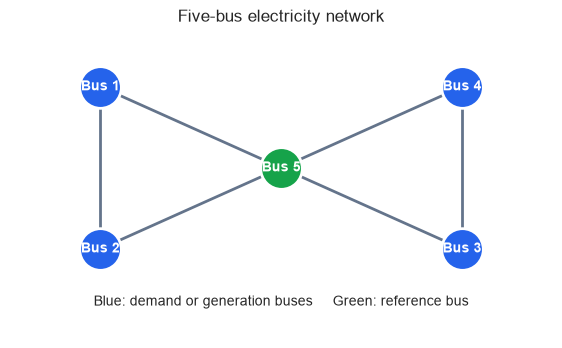

In [18]:
# Draw the five-bus network.
case = paper_case5()
positions = {0: (0.0, 1.0), 1: (0.0, 0.0), 2: (2.0, 0.0), 3: (2.0, 1.0), 4: (1.0, 0.5)}

fig, ax = plt.subplots(figsize=(7, 4))
for branch in case.branches:
    x1, y1 = positions[branch.from_bus]
    x2, y2 = positions[branch.to_bus]
    ax.plot([x1, x2], [y1, y2], color="#64748b", linewidth=2, zorder=1)
for index, label in enumerate(case.bus_labels):
    x, y = positions[index]
    color = "#16a34a" if index == case.slack_bus else "#2563eb"
    ax.scatter(x, y, s=900, color=color, edgecolor="white", linewidth=2, zorder=2)
    ax.text(x, y, f"Bus {label}", color="white", ha="center", va="center", weight="bold", zorder=3)
ax.set_title("Five-bus electricity network")
ax.text(1.0, -0.35, "Blue: demand or generation buses     Green: reference bus", ha="center")
ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.55, 1.35); ax.axis("off"); plt.show()

## 3. First obtain a classical reference

We begin with a conventional fast-decoupled power-flow calculation. This gives us a trusted reference for comparison. Voltage magnitude is measured in per-unit (p.u.): a value near 1.0 represents the intended operating voltage.

In [19]:
classical = solve_fast_decoupled(case, tolerance=1e-6, max_iterations=50)
classical_table = pd.DataFrame({
    "Bus": case.bus_labels,
    "Voltage magnitude (p.u.)": classical.voltage_magnitude,
    "Voltage angle (degrees)": np.degrees(classical.voltage_angle_rad),
})
display(classical_table)
print(f"Converged: {classical.converged}; adjustment rounds: {classical.iterations}")

,Bus,Voltage magnitude (p.u.),Voltage angle (degrees)
0,1,0.94302,-6.44578
1,2,0.94446,-6.45081
2,3,0.99486,-6.55322
3,4,1.01825,-2.24873
4,5,1.00200,0.00000


Converged: True; adjustment rounds: 6


## 4. The complete algorithm and its loop

The application is iterative: it starts with an initial voltage estimate, checks how far that estimate is from the requested power, calculates a correction, and repeats until the remaining mismatch is small.

The fast-decoupled method solves two linear equations during every adjustment round:

$$
B' (V\,\Delta\theta) = \frac{\Delta P}{V},
\qquad
B''\Delta V = \frac{\Delta Q}{V}.
$$

You do not need to perform the matrix algebra yourself:

- $B'$ and $B''$ summarize the electricity-network connections;
- $\Delta P$ and $\Delta Q$ are the present active- and reactive-power imbalances;
- $\Delta\theta$ and $\Delta V$ are the angle and voltage corrections we want to find;
- HHL replaces the classical linear solver for these correction equations.

The loop stops when the largest remaining imbalance is below a small tolerance.

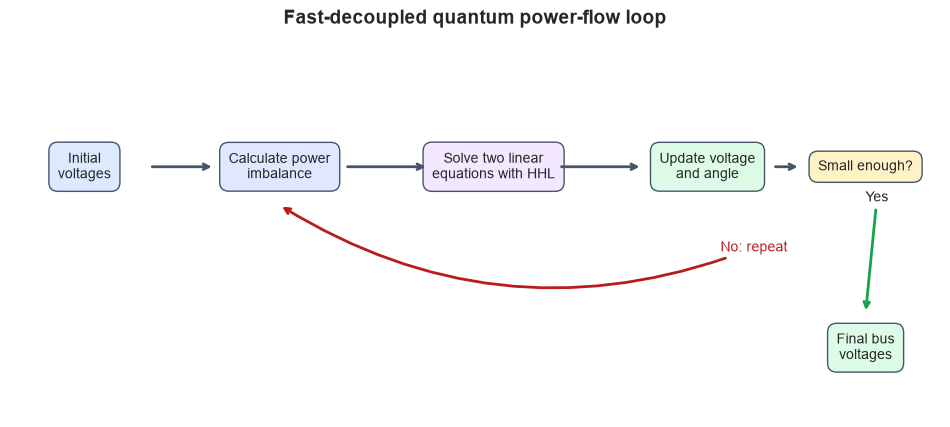

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
steps = {
    "Initial\nvoltages": (0.08, 0.65),
    "Calculate power\nimbalance": (0.29, 0.65),
    "Solve two linear\nequations with HHL": (0.52, 0.65),
    "Update voltage\nand angle": (0.75, 0.65),
    "Small enough?": (0.92, 0.65),
    "Final bus\nvoltages": (0.92, 0.18),
}
colors = ["#dbeafe", "#e0e7ff", "#f3e8ff", "#dcfce7", "#fef3c7", "#dcfce7"]
for (label, (x, y)), color in zip(steps.items(), colors):
    ax.text(x, y, label, transform=ax.transAxes, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.65", facecolor=color, edgecolor="#475569"))
main_labels = list(steps)[:5]
for left, right in zip(main_labels[:-1], main_labels[1:]):
    x1, y1 = steps[left]
    x2, y2 = steps[right]
    ax.annotate("", xy=(x2 - 0.07, y2), xytext=(x1 + 0.07, y1), xycoords=ax.transAxes,
                arrowprops=dict(arrowstyle="->", lw=2, color="#475569"))
ax.annotate("Yes", xy=(0.92, 0.27), xytext=(0.92, 0.56), xycoords=ax.transAxes,
            ha="left", arrowprops=dict(arrowstyle="->", lw=2, color="#16a34a"))
ax.annotate("No: repeat", xy=(0.29, 0.55), xytext=(0.80, 0.43), xycoords=ax.transAxes,
            ha="center", color="#b91c1c",
            arrowprops=dict(arrowstyle="->", lw=2, color="#b91c1c", connectionstyle="arc3,rad=-0.25"))
ax.set_title("Fast-decoupled quantum power-flow loop", fontsize=14, weight="bold")
ax.axis("off")
plt.show()

###  pseudocode

```text
START with an initial voltage at every bus

REPEAT
    calculate the active- and reactive-power imbalance
    ask HHL for angle and voltage corrections
    add the corrections to the present network state
    record the largest remaining imbalance
UNTIL the imbalance is smaller than the tolerance

RETURN the final bus voltages
```

The “repeat” step is important. One HHL call does not solve the complete nonlinear power-flow application. HHL solves linear correction equations inside the larger classical loop.

### See one linear equation

The following cell displays the active-power matrix $B'$ and one representative imbalance vector. The unknown is a four-number correction vector $x$:

$$
B'x=b.
$$

The matrix is fixed by the network. The vector $b$ changes as demand and the current voltage estimate change.

In [21]:
matrix, reactive_matrix = fast_decoupled_matrices(case, mode="reactance_only")
representative_imbalance = np.array([-0.55, -0.55, -0.95, 0.20])

display(pd.DataFrame(matrix, index=["Bus 1", "Bus 2", "Bus 3", "Bus 4"],
                     columns=["Bus 1", "Bus 2", "Bus 3", "Bus 4"]).rename_axis("B′"))
display(pd.DataFrame({
    "Bus": ["Bus 1", "Bus 2", "Bus 3", "Bus 4"],
    "Imbalance b": representative_imbalance,
    "Classical correction x": np.linalg.solve(matrix, representative_imbalance),
}))

,Bus 1,Bus 2,Bus 3,Bus 4
B′,,,,
Bus 1,10.00000,-5.00000,-0.00000,-0.00000
Bus 2,-5.00000,10.00000,-0.00000,-0.00000
Bus 3,-0.00000,-0.00000,10.00000,-5.00000
Bus 4,-0.00000,-0.00000,-5.00000,10.00000


,Bus,Imbalance b,Classical correction x
0,Bus 1,-0.55000,-0.11000
1,Bus 2,-0.55000,-0.11000
2,Bus 3,-0.95000,-0.11333
3,Bus 4,0.20000,-0.03667


## 5. Run the prepared HHL simulation

We use four precision qubits for the first run. Think of these as the part of the quantum workspace that records numerical detail. More precision qubits can represent finer detail, but they also make the circuit larger.

In [22]:
high_precision_factory = QiskitHHLFactory(HHLConfiguration(
    phase_qubits=4, scale_strategy="fixed", fixed_scale=16.0
))
quantum = solve_fast_decoupled(
    case, linear_system_factory=high_precision_factory, tolerance=1e-6, max_iterations=50
)

comparison = pd.DataFrame({
    "Bus": case.bus_labels,
    "Classical (p.u.)": classical.voltage_magnitude,
    "HHL simulation (p.u.)": quantum.voltage_magnitude,
    "Absolute difference": np.abs(classical.voltage_magnitude - quantum.voltage_magnitude),
})
display(comparison)
print(f"Largest voltage difference: {comparison['Absolute difference'].max():.2e} p.u.")

,Bus,Classical (p.u.),HHL simulation (p.u.),Absolute difference
0,1,0.94302,0.94302,0.00000
1,2,0.94446,0.94446,0.00000
2,3,0.99486,0.99486,0.00000
3,4,1.01825,1.01825,0.00000
4,5,1.00200,1.00200,0.00000


Largest voltage difference: 7.38e-08 p.u.


### Watch the solution converge

The solver records one row after every adjustment round. The **maximum mismatch** is the largest remaining disagreement between requested and calculated power. Convergence means that this value falls below the tolerance.

,Round,Maximum mismatch,Bus 3 voltage (p.u.),Bus 4 voltage (p.u.)
0,1,0.14348,1.01398,1.02798
1,2,0.00806,0.99504,1.01841
2,3,0.00131,0.99501,1.01826
3,4,0.00006,0.99486,1.01825
4,5,0.00001,0.99486,1.01825
5,6,0.00000,0.99486,1.01825


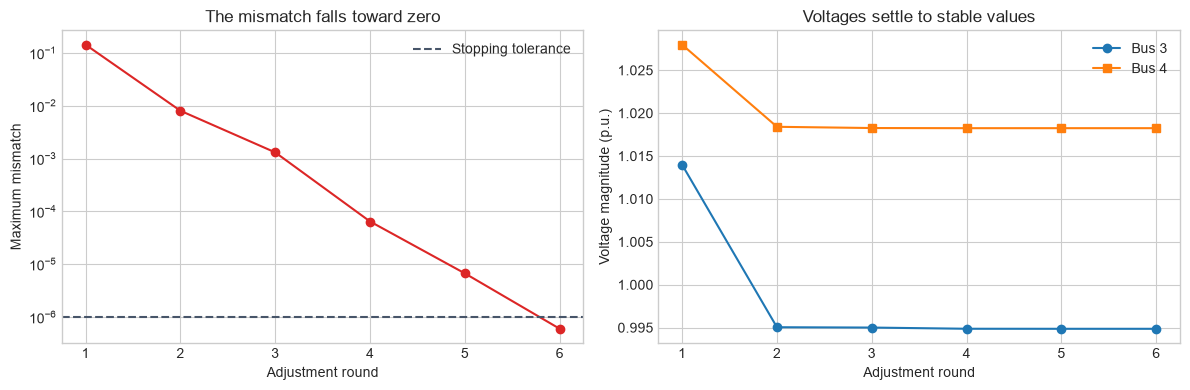

In [23]:
convergence_log = pd.DataFrame({
    "Round": [record.iteration for record in quantum.history],
    "Maximum mismatch": [record.max_mismatch for record in quantum.history],
    "Bus 3 voltage (p.u.)": [record.voltage_magnitude[2] for record in quantum.history],
    "Bus 4 voltage (p.u.)": [record.voltage_magnitude[3] for record in quantum.history],
})
display(convergence_log)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(convergence_log["Round"], convergence_log["Maximum mismatch"], "o-", color="#dc2626")
axes[0].axhline(1e-6, color="#475569", linestyle="--", label="Stopping tolerance")
axes[0].set_xlabel("Adjustment round")
axes[0].set_ylabel("Maximum mismatch")
axes[0].set_title("The mismatch falls toward zero")
axes[0].legend()

axes[1].plot(convergence_log["Round"], convergence_log["Bus 3 voltage (p.u.)"], "o-", label="Bus 3")
axes[1].plot(convergence_log["Round"], convergence_log["Bus 4 voltage (p.u.)"], "s-", label="Bus 4")
axes[1].set_xlabel("Adjustment round")
axes[1].set_ylabel("Voltage magnitude (p.u.)")
axes[1].set_title("Voltages settle to stable values")
axes[1].legend()
fig.tight_layout()
plt.show()

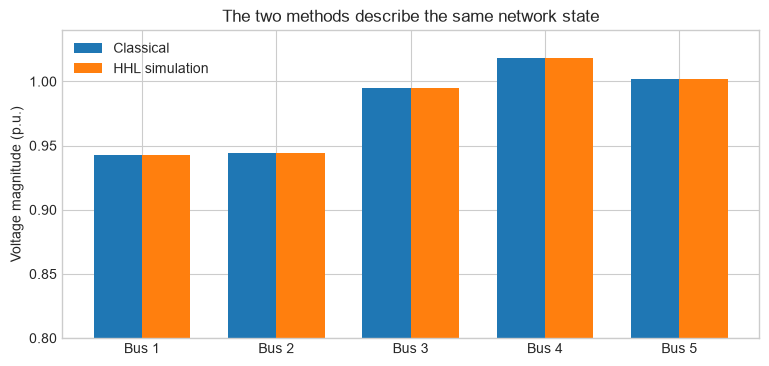

In [24]:
x = np.arange(case.n_buses)
width = 0.36
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, classical.voltage_magnitude, width, label="Classical")
ax.bar(x + width / 2, quantum.voltage_magnitude, width, label="HHL simulation")
ax.set_xticks(x, [f"Bus {label}" for label in case.bus_labels])
ax.set_ylabel("Voltage magnitude (p.u.)")
ax.set_ylim(0.80, 1.04)
ax.set_title("The two methods describe the same network state")
ax.legend(); plt.show()

## 6. View the quantum circuit

Qiskit can draw the circuit constructed by the program. Each horizontal line represents one qubit. Time proceeds from left to right. The boxes represent operations.

Do not try to interpret every box. Notice instead that the application input is prepared first, followed by a sequence of quantum operations. We draw the low-precision version because it is easier to see.

This readable version uses 5 qubits and has raw depth 13.


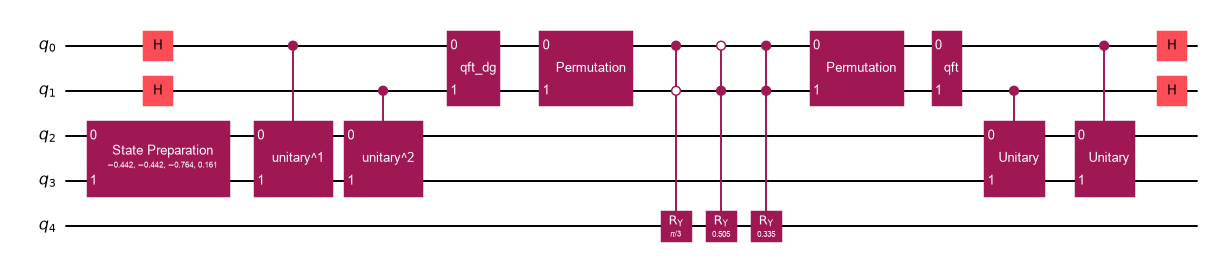

In [25]:
low_precision_system = QiskitHHLFactory(HHLConfiguration(
    phase_qubits=2, scale_strategy="fixed", fixed_scale=16.0
)).prepare(matrix, label="power-flow adjustment")
circuit = low_precision_system.circuit_for_rhs(representative_imbalance)
print(f"This readable version uses {circuit.num_qubits} qubits and has raw depth {circuit.depth()}.")
circuit.draw(output="mpl", fold=25, scale=0.70)

### How to read this circuit without knowing quantum gates

Read the diagram as a sequence of functional blocks rather than individual gates:

1. **State preparation** loads the four-number imbalance into the system qubits (`q2` and `q3`).
2. **Phase estimation** uses the precision qubits (`q0` and `q1`) to record coarse numerical information about the network matrix. The `H`, `QFT`, and unitary blocks belong to this stage.
3. **Controlled rotations** use that recorded information to apply an inverse-like numerical effect. They appear as the controlled `Rᵧ` operations connected to `q4`.
4. **Uncomputation** reverses the temporary phase-estimation work so the system qubits retain the useful solution-state information.

The bottom qubit (`q4`) is an ancilla: a temporary helper used to mark the part associated with the inverse operation. The full numerical workflow must then recover a classically usable correction and return it to the outer power-flow loop.

The main idea is therefore:

$$
\text{encode imbalance} \longrightarrow \text{apply matrix-dependent quantum operations}
\longrightarrow \text{recover a correction}.
$$

This drawing shows the algorithm’s structure. It does not mean that students must construct or memorize the circuit.

## 7. Experiment with electricity demand

Use the control below to choose a demand level. Before running the following cell, predict what will happen to the voltages as demand increases.

Only the demand buses are multiplied. The network connections and reference bus remain unchanged.

In [29]:
demand_control = widgets.SelectionSlider(
    options=[("Normal demand", 1.0), ("Higher demand", 1.3), ("Very high demand", 2.0)],
    value=1.3, description="Demand:", style={"description_width": "initial"}
)
display(demand_control)

SelectionSlider(description='Demand:', index=1, options=(('Normal demand', 1.0), ('Higher demand', 1.3), ('Ver…

,Bus,Normal-demand voltage,Selected-demand classical,Selected-demand HHL
0,1,0.94302,0.85474,0.85474
1,2,0.94446,0.85800,0.85800
2,3,0.99486,0.95345,0.95345
3,4,1.01825,0.99190,0.99190
4,5,1.00200,1.00200,1.00200


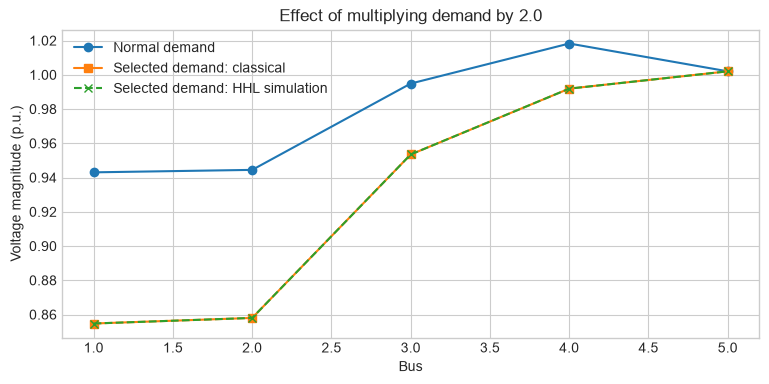

In [28]:
def case_with_demand_multiplier(multiplier):
    base = paper_case5()
    injections = base.specified_power_injection.copy()
    demand_buses = injections.real < 0
    injections[demand_buses] *= multiplier
    return replace(base, name=f"demand_x_{multiplier}", specified_power_injection=injections)

selected_case = case_with_demand_multiplier(demand_control.value)
selected_classical = solve_fast_decoupled(selected_case, tolerance=1e-6, max_iterations=50)
selected_quantum = solve_fast_decoupled(
    selected_case, linear_system_factory=high_precision_factory, tolerance=1e-6, max_iterations=50
)

demand_result = pd.DataFrame({
    "Bus": selected_case.bus_labels,
    "Normal-demand voltage": classical.voltage_magnitude,
    "Selected-demand classical": selected_classical.voltage_magnitude,
    "Selected-demand HHL": selected_quantum.voltage_magnitude,
})
display(demand_result)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(selected_case.bus_labels, classical.voltage_magnitude, "o-", label="Normal demand")
ax.plot(selected_case.bus_labels, selected_classical.voltage_magnitude, "s-", label="Selected demand: classical")
ax.plot(selected_case.bus_labels, selected_quantum.voltage_magnitude, "x--", label="Selected demand: HHL simulation")
ax.set_xlabel("Bus"); ax.set_ylabel("Voltage magnitude (p.u.)")
ax.set_title(f"Effect of multiplying demand by {demand_control.value:.1f}")
ax.legend(); plt.show()

## 8. Experiment with quantum precision

Now keep the physical network fixed and change a quantum-computing parameter. The precision control maps to two, three, or four phase qubits.

A useful result should balance three quantities:

- **adjustment error:** how far one HHL adjustment is from the classical adjustment;
- **adjustment rounds:** how many times the application must update the network;
- **circuit depth:** how many sequential layers of operations are required.

Predict which precision level will use the most resources before running the comparison.

In [30]:
precision_control = widgets.ToggleButtons(
    options=[("Low", 2), ("Medium", 3), ("High", 4)],
    value=2, description="Quantum precision:", style={"description_width": "initial"}
)
display(precision_control)

ToggleButtons(description='Quantum precision:', options=(('Low', 2), ('Medium', 3), ('High', 4)), style=Toggle…

In [34]:
phase_qubits = precision_control.value
selected_factory = QiskitHHLFactory(HHLConfiguration(
    phase_qubits=phase_qubits, scale_strategy="fixed", fixed_scale=16.0
))
selected_precision_result = solve_fast_decoupled(
    case, linear_system_factory=selected_factory, tolerance=1e-6, max_iterations=50
)
prepared = selected_factory.prepare(matrix, label="power-flow adjustment")
adjustment = prepared.solve(representative_imbalance)
statistics = prepared.circuit_statistics()

print(f"Selected phase qubits: {phase_qubits}")
print(f"Total logical qubits: {statistics['logical_qubits']}")
print(f"Compiled circuit depth: {statistics['transpiled_depth']}")
print(f"Representative adjustment error: {100 * adjustment.metadata['relative_solution_error_vs_direct']:.2f}%")
print(f"Power-flow adjustment rounds: {selected_precision_result.iterations}")
print(f"Power flow converged: {selected_precision_result.converged}")

Selected phase qubits: 4
Total logical qubits: 7
Compiled circuit depth: 817
Representative adjustment error: 0.00%
Power-flow adjustment rounds: 6
Power flow converged: True


### Compare all three precision levels

The next cell runs the same problem at every precision level. This is a small experiment: only the quantum precision changes.

,Precision,Phase qubits,Logical qubits,Circuit depth,Adjustment error (%),Adjustment rounds
0,Low,2,5,102,25.00000,14
1,Medium,3,6,220,24.10516,13
2,High,4,7,817,0.00000,6


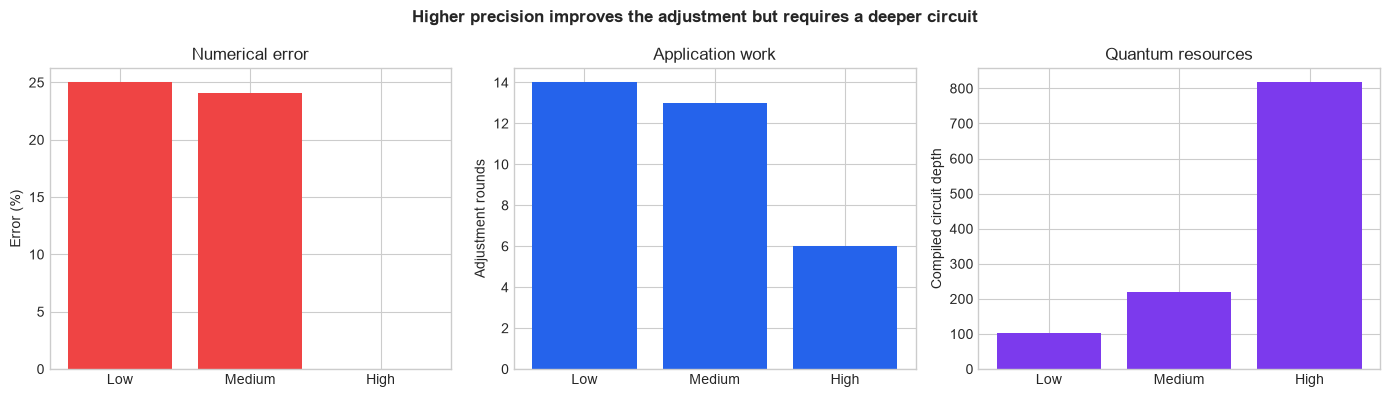

In [32]:
precision_rows = []
for label, phase_qubits in [("Low", 2), ("Medium", 3), ("High", 4)]:
    factory = QiskitHHLFactory(HHLConfiguration(
        phase_qubits=phase_qubits, scale_strategy="fixed", fixed_scale=16.0
    ))
    result = solve_fast_decoupled(case, linear_system_factory=factory, tolerance=1e-6, max_iterations=50)
    prepared = factory.prepare(matrix, label="power-flow adjustment")
    adjustment = prepared.solve(representative_imbalance)
    stats = prepared.circuit_statistics()
    precision_rows.append({
        "Precision": label,
        "Phase qubits": phase_qubits,
        "Logical qubits": stats["logical_qubits"],
        "Circuit depth": stats["transpiled_depth"],
        "Adjustment error (%)": 100 * adjustment.metadata["relative_solution_error_vs_direct"],
        "Adjustment rounds": result.iterations,
    })
precision_table = pd.DataFrame(precision_rows)
display(precision_table)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(precision_table["Precision"], precision_table["Adjustment error (%)"], color="#ef4444")
axes[0].set_title("Numerical error"); axes[0].set_ylabel("Error (%)")
axes[1].bar(precision_table["Precision"], precision_table["Adjustment rounds"], color="#2563eb")
axes[1].set_title("Application work"); axes[1].set_ylabel("Adjustment rounds")
axes[2].bar(precision_table["Precision"], precision_table["Circuit depth"], color="#7c3aed")
axes[2].set_title("Quantum resources"); axes[2].set_ylabel("Compiled circuit depth")
fig.suptitle("Higher precision improves the adjustment but requires a deeper circuit", weight="bold")
fig.tight_layout(); plt.show()

## 9. See a distribution instead of one operating point

Real electricity demand is uncertain. The paper therefore repeats the calculation for 5,000 slightly different, correlated power injections. A **histogram** shows how often a voltage range occurs, while a **scatter plot** shows whether two physical quantities move together.

The figure below follows the stochastic figure used in this project’s paper reproduction:

- the upper-left and lower-right panels show voltage distributions;
- the upper-right panel shows the relationship between bus-3 and bus-4 voltages;
- the lower-left panel shows the correlated input-power variations.

The paper reports a target correlation of 0.75 but does not report the individual variances. This reproduction uses a documented 1% relative standard deviation inferred from the plotted ranges.

In [35]:
b_prime, b_double_prime = fast_decoupled_matrices(case)
active_system = high_precision_factory.prepare(b_prime, label="B_prime")
reactive_system = high_precision_factory.prepare(b_double_prime, label="B_double_prime")
stochastic = run_stochastic_qpf(
    case,
    active_system=active_system,
    reactive_system=reactive_system,
    n_samples=5000,
    relative_standard_deviation=0.01,
    correlation=0.75,
    seed=210404888,
)
samples = stochastic.samples
print(f"Converged samples: {stochastic.converged.sum()} / {len(samples)}")
print(f"Observed voltage correlation: {stochastic.metadata['empirical_voltage_correlation']:.3f}")

Converged samples: 5000 / 5000
Observed voltage correlation: 0.997


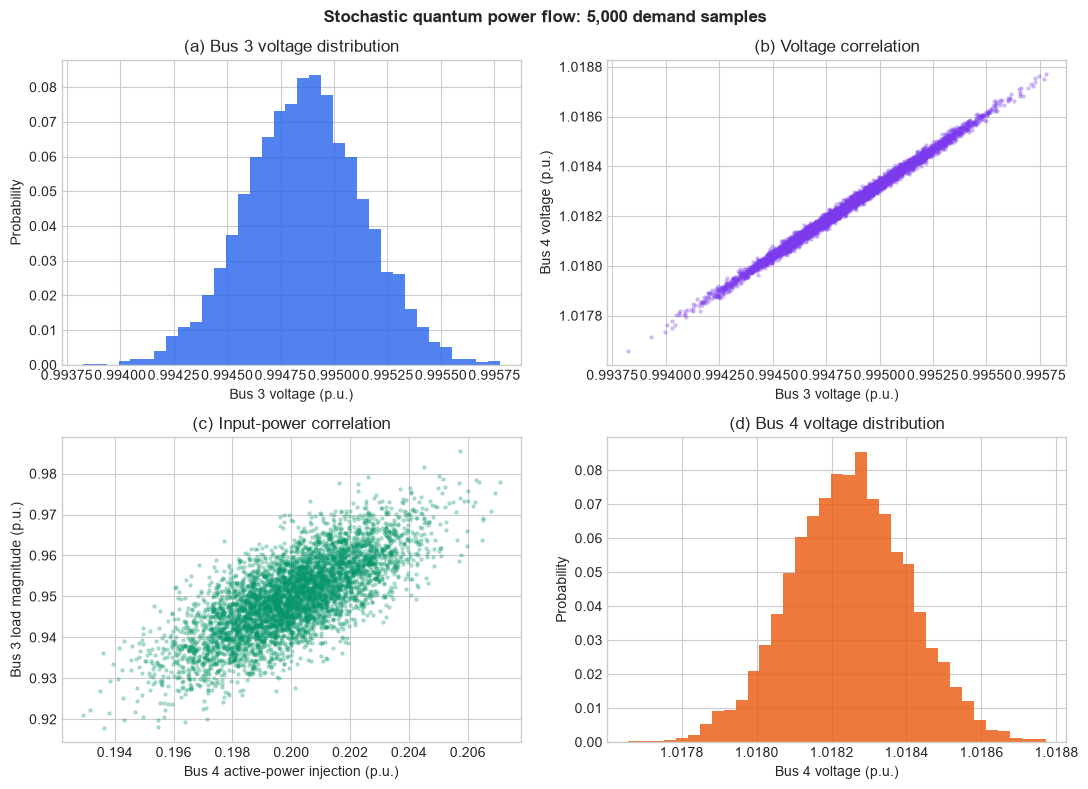

In [36]:
probability_weights = np.ones(len(samples)) / len(samples)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(samples["V3_pu"], bins=35, weights=probability_weights, color="#2563eb", alpha=0.8)
axes[0, 0].set_xlabel("Bus 3 voltage (p.u.)")
axes[0, 0].set_ylabel("Probability")
axes[0, 0].set_title("(a) Bus 3 voltage distribution")

axes[0, 1].scatter(samples["V3_pu"], samples["V4_pu"], s=5, alpha=0.25, color="#7c3aed")
axes[0, 1].set_xlabel("Bus 3 voltage (p.u.)")
axes[0, 1].set_ylabel("Bus 4 voltage (p.u.)")
axes[0, 1].set_title("(b) Voltage correlation")

axes[1, 0].scatter(
    samples["P4_injection_pu"], samples["P3_load_magnitude_pu"],
    s=5, alpha=0.25, color="#059669"
)
axes[1, 0].set_xlabel("Bus 4 active-power injection (p.u.)")
axes[1, 0].set_ylabel("Bus 3 load magnitude (p.u.)")
axes[1, 0].set_title("(c) Input-power correlation")

axes[1, 1].hist(samples["V4_pu"], bins=35, weights=probability_weights, color="#ea580c", alpha=0.8)
axes[1, 1].set_xlabel("Bus 4 voltage (p.u.)")
axes[1, 1].set_ylabel("Probability")
axes[1, 1].set_title("(d) Bus 4 voltage distribution")

fig.suptitle("Stochastic quantum power flow: 5,000 demand samples", weight="bold")
fig.tight_layout()
plt.show()

### Reading the physical result

The narrow histograms mean that the voltage changes are small for these 1% input variations. The diagonal scatter clouds show correlation: when one sampled quantity changes, the other tends to change with it. Each dot is one complete power-flow result, not one quantum measurement shot.

## 10. What should you conclude?

You have used a prepared quantum-algorithm simulation inside a real electricity-network workflow. The experiment demonstrates that:

- the application input changes when electricity demand changes;
- the HHL simulation and the classical solver can converge to almost the same voltage result;
- low quantum precision can make each adjustment less accurate, causing the application to require more rounds;
- higher precision uses more qubits and a deeper circuit;
- uncertain input power produces a distribution of physically meaningful voltage results;
- seeing a correct simulation result does not prove that a noisy quantum computer would produce the same result.

### Reflection questions

1. What happened to the bus voltages when you increased demand?
2. How did the mismatch change across adjustment rounds?
3. Which precision level produced the smallest adjustment error?
4. What resource cost increased with precision?
5. What do the stochastic scatter plots say about relationships between physical quantities?
6. Why did we compare the HHL result with a classical reference?
7. What additional evidence would be needed before claiming an advantage over classical computing?